# PokerBench Oracle Baseline

PokerBench est maintenant la baseline oracle principale pour entra?ner CHECK / FOLD / CALL / RAISE avec des labels solver s?par?s des labels live/legacy.

## Param?tres

Le notebook r?utilise les artefacts existants par d?faut. Mets `FORCE_REBUILD = True` seulement si tu veux relancer l'entra?nement.

In [217]:
from pathlib import Path
import json
import subprocess
import sys
import time

import pandas as pd
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
DATA_DIR = ROOT / "data/pokerbench"
MODEL_DIR = ROOT / "outputs/readiness/pokerbench_oracle_baseline_v1"
REPORT_PATH = MODEL_DIR / "training_report.json"
CONTRACT_PATH = MODEL_DIR / "feature_contract.json"
CANDIDATES_PATH = MODEL_DIR / "candidates.csv"
COMPARISON_PATH = MODEL_DIR / "comparison_with_live_bb_baseline_v1.md"
GRAPHICAL_STUDY_PATH = MODEL_DIR / "graphical_study.md"

RUN_TRAINING = True
RUN_GRAPHICAL_STUDY = True
FAST_MODE = True
FORCE_REBUILD = False
MAX_ROWS = None  # Exemple: 12000 pour un test rapide; None utilise les CSV structur?s disponibles.


def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def run_cmd(args):
    started = time.perf_counter()
    completed = subprocess.run(args, cwd=ROOT, text=True, capture_output=True)
    elapsed = time.perf_counter() - started
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr, file=sys.stderr)
    completed.check_returncode()
    print(f"temps_execution_secondes={elapsed:.2f}")
    return elapsed

## 1. Pr?parer / entra?ner

In [218]:
missing_required = not REPORT_PATH.exists() or not CANDIDATES_PATH.exists() or not (MODEL_DIR / "model.joblib").exists()
missing_graphs = RUN_GRAPHICAL_STUDY and not all((MODEL_DIR / name).exists() for name in [
    "eda_label_distribution.svg",
    "eda_street_distribution.svg",
    "eda_label_by_street.svg",
    "confusion_matrix.svg",
    "feature_importance.svg",
    "feature_correlation.svg",
    "learning_curve.svg",
    "graphical_study.md",
])

if RUN_TRAINING and (FORCE_REBUILD or missing_required or missing_graphs):
    cmd = [
        sys.executable,
        "experiments/pokerbench_oracle_baseline_v1.py",
        "--data-dir",
        str(DATA_DIR),
        "--output-dir",
        str(MODEL_DIR),
    ]
    if DATA_DIR.exists():
        cmd.append("--no-download")
    if MAX_ROWS is not None:
        cmd += ["--max-rows", str(MAX_ROWS)]
    if not FAST_MODE:
        cmd.append("--full-diagnostics")
    run_cmd(cmd)
else:
    print("Artefacts PokerBench r?utilis?s depuis le cache local.")

Artefacts PokerBench r?utilis?s depuis le cache local.


## 2. R?sum? du mod?le

In [219]:
report = load_json(REPORT_PATH)
summary = {
    "baseline": "PokerBench oracle",
    "rows_loaded": report["rows_loaded"],
    "rows_usable": report["rows_usable"],
    "model_type": report["model_type"],
    "accuracy": report["accuracy"],
    "macro_f1": report["macro_f1"],
    "offline_prediction": report["offline_prediction"]["status"],
    "bot_live_connection": report["bot_live_connection"],
}
display(pd.DataFrame([summary]))
display(pd.Series(report["label_distribution"], name="count").to_frame())
display(pd.Series(report["preflop_postflop_distribution"], name="count").to_frame())

,baseline,rows_loaded,rows_usable,model_type,accuracy,macro_f1,offline_prediction,bot_live_connection
0,PokerBench oracle,73200,73200,extra_trees,0.695355,0.71182,ok,not_modified


,count
CALL,27500
CHECK,2700
FOLD,32500
RAISE,10500


,count
postflop,10000
preflop,63200


## 3. Contrat features

In [220]:
contract = load_json(CONTRACT_PATH)
print("classes:", contract["allowed_predictions"])
print("label_source:", contract["label_source"])
print("CALL natif:", contract["call_is_native_class"])
print("leakage utilis? par le mod?le:", contract["leakage_columns_used_by_model"])
display(pd.DataFrame({"feature": contract["features_model_used"]}))

classes: ['CHECK', 'FOLD', 'CALL', 'RAISE']
label_source: pokerbench_solver_oracle
CALL natif: True
leakage utilis? par le mod?le: []


,feature
0,features.pot_bb
1,features.to_call_bb
2,features.hero_stack_bb
3,features.effective_stack_bb
4,features.stack_to_pot_ratio
5,features.to_call_pot_ratio
6,features.has_check
7,features.has_fold
8,features.has_call
9,features.has_raise


## 4. Distributions

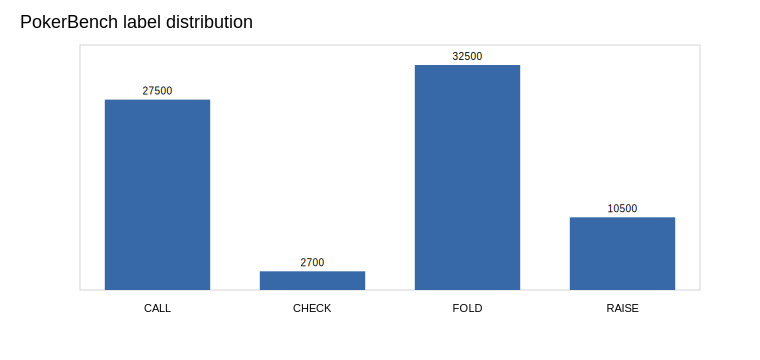

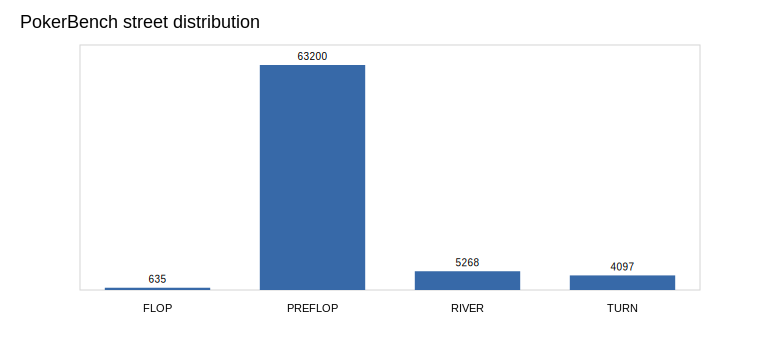

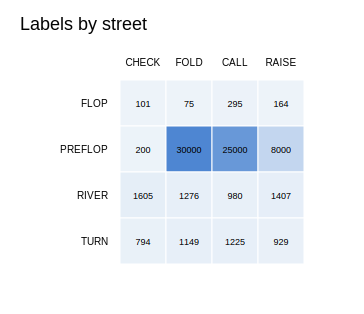

In [221]:
for name in ["eda_label_distribution.svg", "eda_street_distribution.svg", "eda_label_by_street.svg"]:
    path = MODEL_DIR / name
    if path.exists():
        display(SVG(filename=str(path)))

## 5. Performance globale et par classe

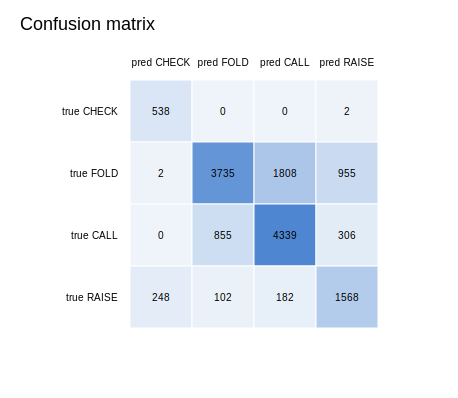

,label,precision,recall,f1,support
0,CHECK,0.682741,0.996296,0.810241,540.0
1,FOLD,0.796036,0.574615,0.667441,6500.0
2,CALL,0.685574,0.788909,0.733621,5500.0
3,RAISE,0.553868,0.746667,0.635976,2100.0


In [222]:
if (MODEL_DIR / "confusion_matrix.svg").exists():
    display(SVG(filename=str(MODEL_DIR / "confusion_matrix.svg")))

rows = []
for label in ["CHECK", "FOLD", "CALL", "RAISE"]:
    metrics = report["classification_report"].get(label, {})
    rows.append({
        "label": label,
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1-score"),
        "support": metrics.get("support"),
    })
display(pd.DataFrame(rows))

## 6. Performance par street

In [223]:
perf = report.get("performance_by_street", {})
display(pd.DataFrame.from_dict(perf, orient="index").sort_index())

,accuracy,macro_f1,rows
FLOP,0.613636,0.492721,132
PREFLOP,0.720783,0.680397,12621
RIVER,0.526710,0.473571,1067
TURN,0.536585,0.544578,820


## 7. Features et corr?lations

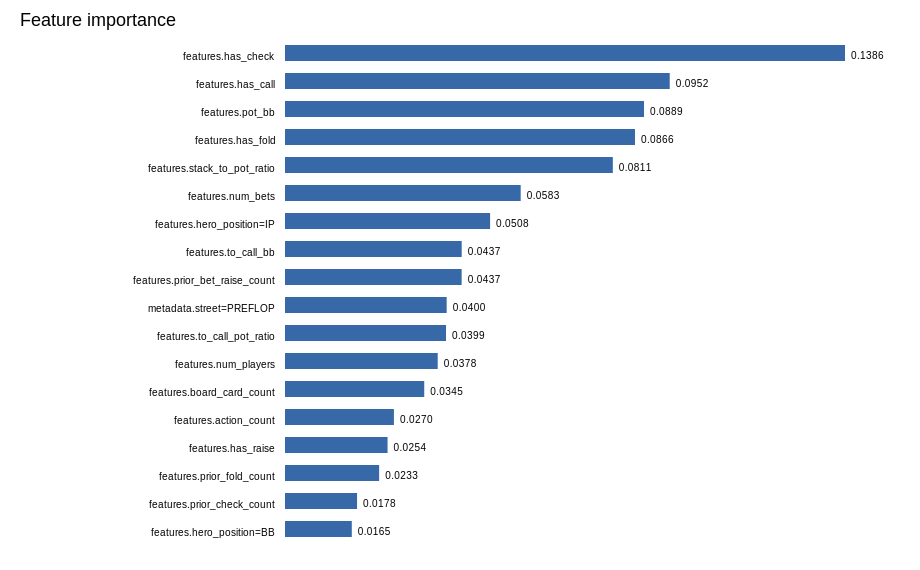

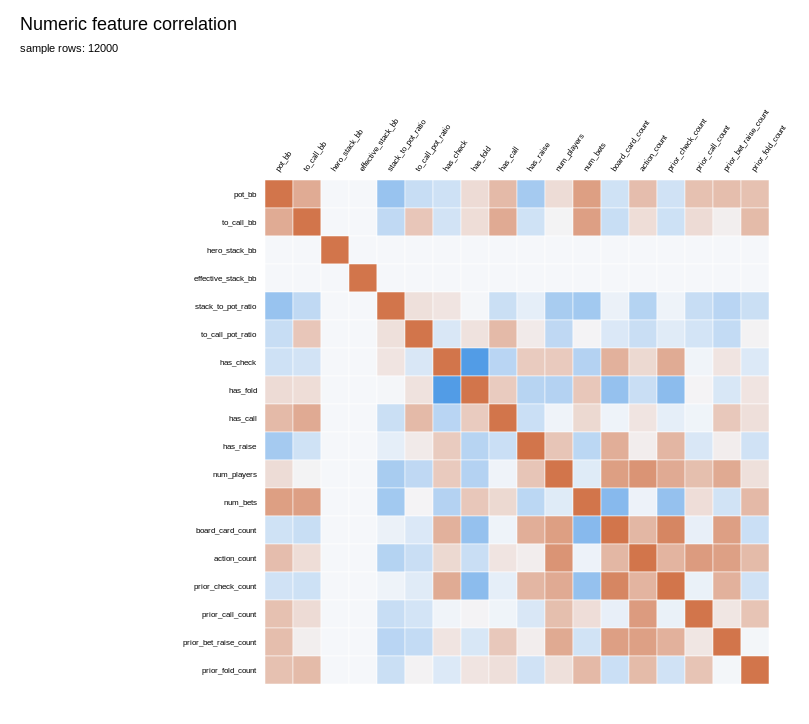

In [224]:
for name in ["feature_importance.svg", "feature_correlation.svg"]:
    path = MODEL_DIR / name
    if path.exists():
        display(SVG(filename=str(path)))

## 8. Learning curve

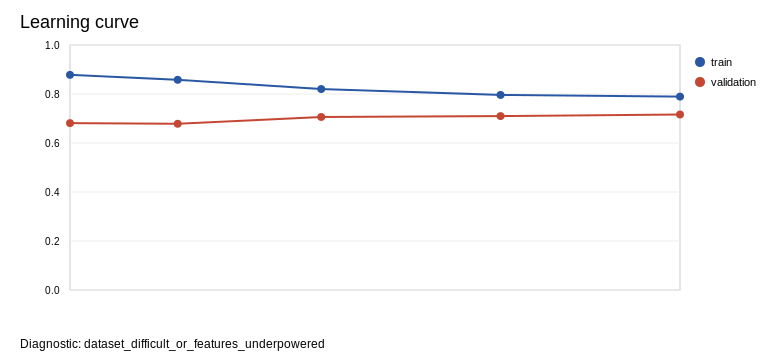

In [225]:
path = MODEL_DIR / "learning_curve.svg"
if path.exists():
    display(SVG(filename=str(path)))

## 9. Synth?se graphique

In [226]:
if GRAPHICAL_STUDY_PATH.exists():
    display(Markdown(GRAPHICAL_STUDY_PATH.read_text(encoding="utf-8")))

# Graphical Study

PokerBench is now the primary oracle baseline. The graphs show a large solver-labeled corpus with four native actions.

## What The Graphs Show

- Labels: `{'CALL': 27500, 'CHECK': 2700, 'FOLD': 32500, 'RAISE': 10500}`.
- Streets: `{'FLOP': 635, 'PREFLOP': 63200, 'RIVER': 5268, 'TURN': 4097}`.
- Global accuracy: `0.695355`, macro F1: `0.71182`.
- Learning diagnostic: `dataset_difficult_or_features_underpowered`.

## Strengths

- Solver-oracle labels are separated from legacy/live labels.
- CALL is a native class.
- Raw prompts/cards/history text are audit-only in this first version.

## Limits

- CHECK is under-represented compared with FOLD and CALL.
- The current lightweight source is dominated by preflop rows.
- Postflop coverage uses the 10k structured set; the large 500k postflop file is not downloaded by default.
- Some numeric context, especially exact call price and stack, is inferred when the CSV does not expose it directly.

## Comparison With Live BB Baseline

- PokerBench oracle: rows `73200`, accuracy `0.695355`, macro F1 `0.71182`.
- live_bb_baseline_v1: rows `None`, accuracy `None`, macro F1 `None`.
- The live baseline score is not directly comparable because its labels are legacy/live-derived and include heavy resampling.

## Recommended Next Action

Add richer PokerBench feature extraction from action history and bring in more structured postflop rows before considering live integration.


## 10. Comparaison baseline historique

In [227]:
if COMPARISON_PATH.exists():
    display(Markdown(COMPARISON_PATH.read_text(encoding="utf-8")))

# pokerbench_oracle_baseline_v1 vs live_bb_baseline_v1

| model | label source | rows | classes | accuracy | macro F1 |
|---|---|---:|---|---:|---:|
| pokerbench_oracle_baseline_v1 | solver oracle | 73200 | CHECK/FOLD/CALL/RAISE | 0.695355 | 0.71182 |
| live_bb_baseline_v1 | legacy/live + limited solver | None | CHECK/FOLD/CALL/RAISE | None | None |

- PokerBench labels are kept separate from legacy labels.
- Neither model is connected to the live bot.


## 11. Pr?diction offline

In [228]:
from experiments.pokerbench_oracle_baseline_v1 import predict_first_row

sample = pd.read_csv(CANDIDATES_PATH, nrows=1).iloc[0].to_dict()
predict_first_row(MODEL_DIR, sample)

{'status': 'ok',
 'prediction': 'FOLD',
 'probabilities': {'CALL': 0.481481,
  'CHECK': 0.0,
  'FOLD': 0.518519,
  'RAISE': 0.0}}

## 12. Archives / baselines historiques

Les anciens flux restent dans `outputs/readiness/` pour comparaison, mais ils ne sont plus le chemin principal de ce notebook.

In [229]:
historical = []
for path in [ROOT / "outputs/readiness/live_bb_baseline_v1/training_report.json"]:
    if path.exists():
        item = load_json(path)
        historical.append({
            "name": path.parent.name,
            "rows": item.get("rows_used"),
            "label_source": item.get("label_source") or item.get("generation_mode"),
            "accuracy": item.get("accuracy"),
            "macro_f1": item.get("macro_f1"),
        })
display(pd.DataFrame(historical))

""


## 13. Tests

In [230]:
RUN_TESTS = False

if RUN_TESTS:
    run_cmd([sys.executable, "-m", "pytest"])
else:
    print("Tests saut?s: RUN_TESTS = False")

Tests saut?s: RUN_TESTS = False


<!-- external_oracle_study_v1 -->
## 14. Etude datasets externes

Cette section pilote les adapters externes sans sortir du notebook. Elle exporte des datasets normalises, charge les rapports, verifie les fuites de texte brut, puis compare les sources.

Les sources PHH/ACPC ajoutees ici sont comportementales: elles donnent des actions observees dans des historiques de mains, pas des labels solver-oracle. Elles sont donc traitees pour audit, pretraining faible, imitation separee ou relabeling futur, mais restent exclues du merge supervised PokerBench/GTO par defaut.


In [231]:
# Parametres pour les datasets externes
RUN_EXTERNAL_EXPORTS = True   # Mets True pour regenerer les exports/adapters.
EXTERNAL_SAMPLE_SIZE = 1000   # Exemple rapide. Mets None seulement quand tu veux tout exporter.
FORCE_EXTERNAL_EXPORT = True

PHH_INPUT_ROOT = ROOT / "data/phh"
PHH_INPUT_PATHS = {
    "phh_handhq_nlhe": PHH_INPUT_ROOT / "handhq",
    "phh_pluribus": PHH_INPUT_ROOT / "pluribus",
    "phh_wsop_tv": PHH_INPUT_ROOT / "wsop",
    "acpc_public_logs": PHH_INPUT_ROOT / "acpc",
}

EXTERNAL_DATASETS = {
    "poker_gto_100k": ROOT / "outputs/readiness/poker_gto_100k_oracle_v1",
    "gtow_llama_sft_v3": ROOT / "outputs/readiness/gtow_llama_sft_v3_oracle_v1",
    "phh_handhq_nlhe": ROOT / "outputs/readiness/phh_handhq_nlhe_behavioral_v1",
    "phh_pluribus": ROOT / "outputs/readiness/phh_pluribus_behavioral_v1",
    "phh_wsop_tv": ROOT / "outputs/readiness/phh_wsop_tv_behavioral_v1",
    "acpc_public_logs": ROOT / "outputs/readiness/acpc_public_logs_behavioral_v1",
}

BEHAVIORAL_HISTORY_SOURCES = set(PHH_INPUT_PATHS)

EXTERNAL_RAW_TEXT_COLUMNS = {
    "raw_prompt",
    "raw_instruction",
    "raw_response",
    "raw_output",
    "raw_chosen",
    "raw_rejected",
    "raw_metadata_json",
    "raw_record_json",
}

EXTERNAL_FEATURE_20 = [
    "features.pot_bb",
    "features.to_call_bb",
    "features.hero_stack_bb",
    "features.effective_stack_bb",
    "features.stack_to_pot_ratio",
    "features.to_call_pot_ratio",
    "features.has_check",
    "features.has_fold",
    "features.has_call",
    "features.has_raise",
    "features.num_players",
    "features.num_bets",
    "features.board_card_count",
    "features.action_count",
    "features.prior_check_count",
    "features.prior_call_count",
    "features.prior_bet_raise_count",
    "features.prior_fold_count",
    "metadata.street",
    "features.hero_position",
]

print("Interaction conseillee:")
print("1. Les archives PHH lourdes ne sont pas telechargees automatiquement.")
print("2. Place les .phh/.phhs locaux sous data/phh/handhq, data/phh/pluribus, data/phh/wsop ou data/phh/acpc.")
print("3. Garde EXTERNAL_SAMPLE_SIZE=1000 tant que tu explores.")
print("4. PHH/ACPC = behavioral/weak labels; PokerBench reste la baseline solver-oracle.")


Interaction conseillee:
1. Les archives PHH lourdes ne sont pas telechargees automatiquement.
2. Place les .phh/.phhs locaux sous data/phh/handhq, data/phh/pluribus, data/phh/wsop ou data/phh/acpc.
3. Garde EXTERNAL_SAMPLE_SIZE=1000 tant que tu explores.
4. PHH/ACPC = behavioral/weak labels; PokerBench reste la baseline solver-oracle.


### 14.1 Generer ou reutiliser les exports externes

In [232]:
if RUN_EXTERNAL_EXPORTS:
    for source, output_dir in EXTERNAL_DATASETS.items():
        cmd = [
            sys.executable,
            "datasets/export_external_oracle_dataset.py",
            "--source",
            source,
            "--output-dir",
            str(output_dir),
        ]
        if source in PHH_INPUT_PATHS:
            input_path = PHH_INPUT_PATHS[source]
            if input_path.exists():
                cmd += ["--input-path", str(input_path)]
            else:
                print(f"{source}: chemin local absent ({input_path}); export manifest vide, aucun download lourd.")
        if EXTERNAL_SAMPLE_SIZE is not None:
            cmd += ["--sample-size", str(EXTERNAL_SAMPLE_SIZE)]
        if FORCE_EXTERNAL_EXPORT:
            cmd.append("--force")
        run_cmd(cmd)
else:
    print("Exports externes reutilises depuis outputs/readiness/. Mets RUN_EXTERNAL_EXPORTS=True pour regenerer.")


{
  "generation_timestamp": "2026-06-01T02:42:11.850377+00:00",
  "label_distribution_3intent": {
    "CALL": 315,
    "NO_INVEST": 534,
    "RAISE": 151
  },
  "leakage_warnings": [
    "raw prompt/instruction/output/chosen/rejected fields are written only to audit_candidates.csv",
    "model_input.csv excludes raw text answer fields by default"
  ],
  "missing_field_rates": {
    "action_history": 0.0,
    "bet_size": 0.849,
    "board_cards": 0.0,
    "effective_stack": 0.0,
    "equity": 0.001,
    "ev": 0.0,
    "hand_id": 1.0,
    "hero_cards": 0.0,
    "hero_position": 0.0,
    "label_3intent": 0.0,
    "leakage_risk_notes": 0.0,
    "legal_actions": 0.0,
    "normalized_action_4class": 0.0,
    "pot_size": 0.0,
    "raw_action": 0.0,
    "source_dataset": 0.0,
    "source_license": 0.0,
    "source_row_id": 0.0,
    "source_split": 0.0,
    "source_url": 0.0,
    "street": 0.0,
    "villain_position": 0.0
  },
  "pokerbench_feature_compatibility_file": "model_features_20.csv",


### 14.2 Rapports de couverture et distribution des labels

In [233]:
external_reports = []
for source, output_dir in EXTERNAL_DATASETS.items():
    report_path = output_dir / "dataset_report.json"
    if not report_path.exists():
        external_reports.append({
            "source": source,
            "status": "missing_report",
            "path": str(report_path),
        })
        continue
    item = load_json(report_path)
    external_reports.append({
        "source": source,
        "status": "ok",
        "rows_loaded": item.get("rows_loaded"),
        "rows_usable": item.get("rows_usable"),
        "rows_dropped": item.get("rows_dropped"),
        "labels": item.get("label_distribution_3intent"),
        "terms": item.get("source_license_or_terms"),
        "next_step": item.get("recommended_next_step"),
    })

reports_df = pd.DataFrame(external_reports)
display(reports_df)

label_rows = []
for row in external_reports:
    for label, count in (row.get("labels") or {}).items():
        label_rows.append({"source": row["source"], "label_3intent": label, "count": count})
if label_rows:
    display(pd.DataFrame(label_rows).pivot_table(index="source", columns="label_3intent", values="count", fill_value=0))

,source,status,rows_loaded,rows_usable,rows_dropped,labels,terms,next_step
0,poker_gto_100k,ok,1000,1000,0,"{'CALL': 315, 'NO_INVEST': 534, 'RAISE': 151}",agpl-3.0 per Hugging Face listing; verify curr...,Compare normalized field coverage against Poke...
1,gtow_llama_sft_v3,ok,1000,1000,0,"{'CALL': 247, 'NO_INVEST': 456, 'RAISE': 297}",Derived from GTO Wizard API; verify terms befo...,Audit terms and compare heads-up 200BB coverag...
2,phh_handhq_nlhe,ok,0,0,0,{},CC-BY-4.0 for the Zenodo distribution; condens...,"Use as behavioral pretraining, weak labels, an..."
3,phh_pluribus,ok,0,0,0,{},CC-BY-4.0 via the PHH Zenodo distribution; ver...,Use as expert demonstrations and error-analysi...
4,phh_wsop_tv,ok,0,0,0,{},CC-BY-4.0 via the PHH Zenodo distribution; ver...,Use as a notebook case study and qualitative s...
5,acpc_public_logs,ok,0,0,0,{},License not specified in the user-provided sou...,Use only for a dedicated heads-up module or ac...


label_3intent,CALL,NO_INVEST,RAISE
source,,,
gtow_llama_sft_v3,247.0,456.0,297.0
poker_gto_100k,315.0,534.0,151.0


### 14.3 Champs manquants et risques de distribution

In [234]:
missing_rows = []
for source, output_dir in EXTERNAL_DATASETS.items():
    report_path = output_dir / "dataset_report.json"
    if not report_path.exists():
        continue
    item = load_json(report_path)
    for field, rate in (item.get("missing_field_rates") or {}).items():
        missing_rows.append({"source": source, "field": field, "missing_rate": rate})

missing_df = pd.DataFrame(missing_rows)
if not missing_df.empty:
    important_fields = [
        "street",
        "hero_position",
        "hero_cards",
        "board_cards",
        "pot_size",
        "effective_stack",
        "legal_actions",
        "ev",
        "equity",
        "label_3intent",
    ]
    display(
        missing_df[missing_df["field"].isin(important_fields)]
        .pivot_table(index="field", columns="source", values="missing_rate", fill_value=0)
        .sort_index()
    )
else:
    print("Aucun rapport de champs manquants disponible.")

source,acpc_public_logs,gtow_llama_sft_v3,phh_handhq_nlhe,phh_pluribus,phh_wsop_tv,poker_gto_100k
field,,,,,,
board_cards,1.0,0.368,1.0,1.0,1.0,0.000
effective_stack,1.0,0.000,1.0,1.0,1.0,0.000
equity,1.0,1.000,1.0,1.0,1.0,0.001
ev,1.0,1.000,1.0,1.0,1.0,0.000
hero_cards,1.0,0.000,1.0,1.0,1.0,0.000
hero_position,1.0,0.000,1.0,1.0,1.0,0.000
label_3intent,1.0,0.000,1.0,1.0,1.0,0.000
legal_actions,1.0,0.000,1.0,1.0,1.0,0.000
pot_size,1.0,0.000,1.0,1.0,1.0,0.000


### 14.4 Verification anti-leakage

In [235]:
leakage_checks = []
for source, output_dir in EXTERNAL_DATASETS.items():
    model_input = output_dir / "model_input.csv"
    feature_20 = output_dir / "model_features_20.csv"
    audit = output_dir / "audit_candidates.csv"
    for kind, path in [("model_input", model_input), ("model_features_20", feature_20), ("audit", audit)]:
        if not path.exists():
            leakage_checks.append({"source": source, "file": kind, "exists": False})
            continue
        header = pd.read_csv(path, nrows=0).columns.tolist()
        raw_cols_present = sorted(set(header) & EXTERNAL_RAW_TEXT_COLUMNS)
        leakage_checks.append({
            "source": source,
            "file": kind,
            "exists": True,
            "raw_text_columns_present": raw_cols_present,
            "ok_for_model_input": kind == "audit" or not raw_cols_present,
        })

display(pd.DataFrame(leakage_checks))

,source,file,exists,raw_text_columns_present,ok_for_model_input
0,poker_gto_100k,model_input,True,[],True
1,poker_gto_100k,model_features_20,True,[],True
2,poker_gto_100k,audit,True,"[raw_chosen, raw_metadata_json, raw_prompt, ra...",True
3,gtow_llama_sft_v3,model_input,True,[],True
4,gtow_llama_sft_v3,model_features_20,True,[],True
5,gtow_llama_sft_v3,audit,True,"[raw_instruction, raw_output, raw_prompt, raw_...",True
6,phh_handhq_nlhe,model_input,True,[],True
7,phh_handhq_nlhe,model_features_20,True,[],True
8,phh_handhq_nlhe,audit,True,[],True
9,phh_pluribus,model_input,True,[],True


### 14.5 Apercu des donnees exportees

In [236]:
for source, output_dir in EXTERNAL_DATASETS.items():
    model_input = output_dir / "model_input.csv"
    feature_20 = output_dir / "model_features_20.csv"
    display(Markdown(f"#### {source}"))
    if model_input.exists():
        display(pd.read_csv(model_input, nrows=5))
    else:
        print("model_input.csv absent")
    if feature_20.exists():
        display(Markdown("Features compatibles PokerBench 20 colonnes"))
        display(pd.read_csv(feature_20, nrows=5))

#### poker_gto_100k

,source_dataset,source_row_id,source_split,hand_id,street,hero_position,villain_position,hero_cards,board_cards,pot_size,...,legal_actions,raw_action,normalized_action_4class,label_3intent,bet_size,ev,equity,source_license,source_url,leakage_risk_notes
0,jevonmao/poker-gto-100k,action_sft:train:0,train,NaN,FLOP,SB,BB,8cKs,2c2d2h,500.0,...,"check, bet 165, bet 375.",<action>check</action>,CHECK,NO_INVEST,NaN,254.0,58.4,agpl-3.0 per Hugging Face listing; verify curr...,https://huggingface.co/datasets/jevonmao/poker...,prompt/response/chosen/rejected contain answer...
1,jevonmao/poker-gto-100k,action_sft:train:1,train,NaN,FLOP,SB,BB,3c5d,2c2d2h,500.0,...,"check, bet 165, bet 375.",<action>bet 375</action>,RAISE,RAISE,375.0,148.0,28.4,agpl-3.0 per Hugging Face listing; verify curr...,https://huggingface.co/datasets/jevonmao/poker...,prompt/response/chosen/rejected contain answer...
2,jevonmao/poker-gto-100k,action_sft:train:2,train,NaN,FLOP,SB,BB,5cKd,2c2d2h,500.0,...,"check, bet 165, bet 375.",<action>check</action>,CHECK,NO_INVEST,NaN,234.0,57.3,agpl-3.0 per Hugging Face listing; verify curr...,https://huggingface.co/datasets/jevonmao/poker...,prompt/response/chosen/rejected contain answer...
3,jevonmao/poker-gto-100k,action_sft:train:3,train,NaN,TURN,BB,SB,8hAc,2c2d2h3h,500.0,...,"check, bet 375.",<action>bet 375</action>,RAISE,RAISE,375.0,432.0,73.3,agpl-3.0 per Hugging Face listing; verify curr...,https://huggingface.co/datasets/jevonmao/poker...,prompt/response/chosen/rejected contain answer...
4,jevonmao/poker-gto-100k,action_sft:train:4,train,NaN,TURN,BB,SB,8cAs,2c2d2h3h,500.0,...,"check, bet 375.",<action>bet 375</action>,RAISE,RAISE,375.0,434.0,73.6,agpl-3.0 per Hugging Face listing; verify curr...,https://huggingface.co/datasets/jevonmao/poker...,prompt/response/chosen/rejected contain answer...


Features compatibles PokerBench 20 colonnes

,features.pot_bb,features.to_call_bb,features.hero_stack_bb,features.effective_stack_bb,features.stack_to_pot_ratio,features.to_call_pot_ratio,features.has_check,features.has_fold,features.has_call,features.has_raise,...,features.action_count,features.prior_check_count,features.prior_call_count,features.prior_bet_raise_count,features.prior_fold_count,metadata.street,features.hero_position,label_3intent,source_dataset,source_row_id
0,5.0,0.0,197.5,197.5,39.5,0.0,1.0,0.0,0.0,1.0,...,3.0,1.0,1.0,1.0,0.0,FLOP,SB,NO_INVEST,jevonmao/poker-gto-100k,action_sft:train:0
1,5.0,0.0,197.5,197.5,39.5,0.0,1.0,0.0,0.0,1.0,...,3.0,1.0,1.0,1.0,0.0,FLOP,SB,RAISE,jevonmao/poker-gto-100k,action_sft:train:1
2,5.0,0.0,197.5,197.5,39.5,0.0,1.0,0.0,0.0,1.0,...,3.0,1.0,1.0,1.0,0.0,FLOP,SB,NO_INVEST,jevonmao/poker-gto-100k,action_sft:train:2
3,5.0,0.0,197.5,197.5,39.5,0.0,1.0,0.0,0.0,1.0,...,4.0,2.0,1.0,1.0,0.0,TURN,BB,RAISE,jevonmao/poker-gto-100k,action_sft:train:3
4,5.0,0.0,197.5,197.5,39.5,0.0,1.0,0.0,0.0,1.0,...,4.0,2.0,1.0,1.0,0.0,TURN,BB,RAISE,jevonmao/poker-gto-100k,action_sft:train:4


#### gtow_llama_sft_v3

...

,features.pot_bb,features.to_call_bb,features.hero_stack_bb,features.effective_stack_bb,features.stack_to_pot_ratio,features.to_call_pot_ratio,features.has_check,features.has_fold,features.has_call,features.has_raise,...,features.action_count,features.prior_check_count,features.prior_call_count,features.prior_bet_raise_count,features.prior_fold_count,metadata.street,features.hero_position,label_3intent,source_dataset,source_row_id


#### acpc_public_logs

,source_dataset,source_row_id,source_split,hand_id,street,hero_position,villain_position,hero_cards,board_cards,pot_size,...,legal_actions,raw_action,normalized_action_4class,label_3intent,bet_size,ev,equity,source_license,source_url,leakage_risk_notes


Features compatibles PokerBench 20 colonnes

,features.pot_bb,features.to_call_bb,features.hero_stack_bb,features.effective_stack_bb,features.stack_to_pot_ratio,features.to_call_pot_ratio,features.has_check,features.has_fold,features.has_call,features.has_raise,...,features.action_count,features.prior_check_count,features.prior_call_count,features.prior_bet_raise_count,features.prior_fold_count,metadata.street,features.hero_position,label_3intent,source_dataset,source_row_id


### 14.6 Decision pratique

Ce que tu dois faire dans le notebook:

1. Executer les cellules jusqu'a cette section.
2. Verifier que `model_input.csv` et `model_features_20.csv` n'ont pas de colonnes `raw_*`.
3. Lire les distributions `NO_INVEST / CALL / RAISE` pour voir si le sample est equilibre.
4. Si le sample de 1000 lignes semble correct, augmenter `EXTERNAL_SAMPLE_SIZE` progressivement.
5. Pour PHH HandHQ, PHH Pluribus, PHH WSOP TV et ACPC, garder `source_dataset` et `source_type`: ce sont des actions observees, pas des gold labels solver.
6. Ne pas melanger PHH/ACPC avec PokerBench pour entrainer le modele oracle tant qu'il n'y a pas de relabeling solver ou un objectif imitation separe.

Decision conseillee maintenant: garder PokerBench comme baseline principale, utiliser les datasets externes solver-like pour audit/comparaison, et utiliser PHH/ACPC comme corpus comportemental separe.


<!-- merged_oracle_router_v1 -->
## 15. Fusion oracle 3 sources et modeles preflop/postflop

Cette section fusionne PokerBench + `poker-gto-100k` + `gtow-llama-sft-v3`, puis entraine deux modeles separes: un modele PREFLOP et un modele POSTFLOP. PHH/ACPC reste exclu du supervised oracle training car ce sont des historiques comportementaux.


In [237]:
MERGED_DIR = ROOT / "outputs/readiness/merged_oracle_3intent_v1"
MERGE_REPORT_PATH = MERGED_DIR / "merge_report.json"
PREFLOP_MODEL_DIR = ROOT / "outputs/readiness/merged_oracle_preflop_model_v1"
POSTFLOP_MODEL_DIR = ROOT / "outputs/readiness/merged_oracle_postflop_model_v1"
PREFLOP_REPORT_PATH = PREFLOP_MODEL_DIR / "training_report.json"
POSTFLOP_REPORT_PATH = POSTFLOP_MODEL_DIR / "training_report.json"
MERGED_COMPARISON_PATH = ROOT / "outputs/readiness/merged_oracle_preflop_postflop_comparison_v1.md"

RUN_MERGE = not MERGE_REPORT_PATH.exists()
RUN_MERGED_TRAINING = not (PREFLOP_REPORT_PATH.exists() and POSTFLOP_REPORT_PATH.exists())
MERGED_SAMPLE_SIZE = None  # Exemple rapide: 1000. None reutilise toutes les lignes deja exportees.
FORCE_MERGE = False
FORCE_MERGED_TRAINING = False

print("RUN_MERGE=", RUN_MERGE)
print("RUN_MERGED_TRAINING=", RUN_MERGED_TRAINING)
print("MERGED_SAMPLE_SIZE=", MERGED_SAMPLE_SIZE)

RUN_MERGE= False
RUN_MERGED_TRAINING= False
MERGED_SAMPLE_SIZE= None


### 15.1 G?n?rer ou r?utiliser le dataset fusionn?

In [238]:
if RUN_MERGE or FORCE_MERGE:
    cmd = [
        sys.executable,
        "datasets/merge_oracle_3intent_dataset.py",
        "--output-dir",
        str(MERGED_DIR),
    ]
    if MERGED_SAMPLE_SIZE is not None:
        cmd += ["--sample-size-per-source", str(MERGED_SAMPLE_SIZE)]
    if FORCE_MERGE:
        cmd.append("--force")
    run_cmd(cmd)
else:
    print("Dataset fusionne reutilise:", MERGED_DIR)

Dataset fusionne reutilise: c:\Users\polo\Pictures\Cours Info\Programme\Traine_aide_decission\outputs\readiness\merged_oracle_3intent_v1


### 15.2 Rapport de fusion

In [239]:
merge_report = load_json(MERGE_REPORT_PATH)
display(pd.DataFrame([{
    "rows_total": sum(merge_report.get("source_rows", {}).values()),
    "preflop": merge_report.get("stage_group_distribution", {}).get("PREFLOP"),
    "postflop": merge_report.get("stage_group_distribution", {}).get("POSTFLOP"),
    "unknown_excluded": merge_report.get("unknown_stage_rows_excluded"),
    "warnings": ", ".join(merge_report.get("warnings", [])),
}]))

display(pd.Series(merge_report.get("source_rows", {}), name="rows").to_frame())
display(pd.Series(merge_report.get("stage_group_distribution", {}), name="rows").to_frame())

display(pd.DataFrame(merge_report.get("label_distribution_by_source", {})).fillna(0).astype(int))
display(pd.DataFrame(merge_report.get("label_distribution_by_stage", {})).fillna(0).astype(int))

,rows_total,preflop,postflop,unknown_excluded,warnings
0,75200,63568,11632,0,


,rows
PokerBench,73200
jevonmao/gtow-llama-sft-v3,1000
jevonmao/poker-gto-100k,1000


,rows
POSTFLOP,11632
PREFLOP,63568


,PokerBench,jevonmao/gtow-llama-sft-v3,jevonmao/poker-gto-100k
CALL,27500,247,315
NO_INVEST,35200,456,534
RAISE,10500,297,151


,POSTFLOP,PREFLOP
CALL,2939,25123
NO_INVEST,5926,30264
RAISE,2767,8181


### 15.3 Champs manquants et anti-leakage

In [240]:
missing = merge_report.get("missing_feature_rates", {})
display(pd.Series(missing, name="missing_rate").to_frame())

leakage_summary = {
    "leakage_columns_used_by_x": merge_report.get("leakage_columns_used_by_x"),
    "source_dataset_excluded_from_x": merge_report.get("source_dataset_excluded_from_x"),
    "raw_text_columns_excluded_from_x": merge_report.get("raw_text_columns_excluded_from_x"),
    "excluded_sources": merge_report.get("excluded_sources"),
}
display(Markdown("json" + json.dumps(leakage_summary, ensure_ascii=False, indent=2) + ""))

for filename in ["X_train_preflop.csv", "X_train_postflop.csv"]:
    path = MERGED_DIR / filename
    header = pd.read_csv(path, nrows=0).columns.tolist()
    forbidden = sorted(set(header) & {"source_dataset", "source_row_id", "label_3intent", "raw_prompt", "raw_response", "raw_action"})
    print(filename, "forbidden_columns=", forbidden)

,missing_rate
features.action_count,0.0
features.board_card_count,0.0
features.effective_stack_bb,0.0
features.has_call,0.0
features.has_check,0.0
features.has_fold,0.0
features.has_raise,0.0
features.hero_position,0.0
features.hero_stack_bb,0.0
features.num_bets,0.0


json{
  "leakage_columns_used_by_x": [],
  "source_dataset_excluded_from_x": true,
  "raw_text_columns_excluded_from_x": [
    "raw_chosen",
    "raw_instruction",
    "raw_metadata_json",
    "raw_output",
    "raw_prompt",
    "raw_record_json",
    "raw_rejected",
    "raw_response"
  ],
  "excluded_sources": {
    "PHH / Zenodo ACPC HUNL": "excluded: scaffold/expert hand-history source, not direct solver/GTO labels"
  }
}

X_train_preflop.csv forbidden_columns= []
X_train_postflop.csv forbidden_columns= []


### 15.4 Entra?ner ou r?utiliser les mod?les pr?flop/postflop

In [241]:
if RUN_MERGED_TRAINING or FORCE_MERGED_TRAINING:
    cmd = [
        sys.executable,
        "experiments/merged_oracle_preflop_postflop_v1.py",
        "--data-dir",
        str(MERGED_DIR),
        "--output-root",
        str(ROOT / "outputs/readiness"),
    ]
    if FORCE_MERGED_TRAINING:
        cmd.append("--force")
    run_cmd(cmd)
else:
    print("Modeles fusionnes reutilises depuis outputs/readiness/.")

Modeles fusionnes reutilises depuis outputs/readiness/.


### 15.5 R?sultats mod?les

In [242]:
preflop_report = load_json(PREFLOP_REPORT_PATH)
postflop_report = load_json(POSTFLOP_REPORT_PATH)
model_rows = []
for name, item in [("preflop", preflop_report), ("postflop", postflop_report)]:
    model_rows.append({
        "model": name,
        "rows_train": item.get("rows_train"),
        "rows_validation": item.get("rows_validation"),
        "rows_test": item.get("rows_test"),
        "accuracy": item.get("accuracy"),
        "macro_f1": item.get("macro_f1"),
        "weighted_f1": item.get("weighted_f1"),
        "recall_NO_INVEST": item.get("classification_report", {}).get("NO_INVEST", {}).get("recall"),
        "recall_CALL": item.get("classification_report", {}).get("CALL", {}).get("recall"),
        "recall_RAISE": item.get("classification_report", {}).get("RAISE", {}).get("recall"),
    })
display(pd.DataFrame(model_rows))

for title, item in [("Preflop sources", preflop_report), ("Postflop sources", postflop_report)]:
    display(Markdown(f"#### {title}"))
    display(pd.DataFrame.from_dict(item.get("performance_by_source_dataset", {}), orient="index"))

,model,rows_train,rows_validation,rows_test,accuracy,macro_f1,weighted_f1,recall_NO_INVEST,recall_CALL,recall_RAISE
0,preflop,44497,6357,12714,0.717319,0.713274,0.714268,0.575578,0.816610,0.938927
1,postflop,8143,1163,2326,0.549441,0.532605,0.553995,0.531197,0.659091,0.461832


#### Preflop sources

,accuracy,macro_f1,rows
PokerBench,0.717395,0.712972,12636
jevonmao/gtow-llama-sft-v3,0.705128,0.604170,78


#### Postflop sources

,accuracy,macro_f1,rows
PokerBench,0.540310,0.525951,1997
jevonmao/gtow-llama-sft-v3,0.685039,0.601384,127
jevonmao/poker-gto-100k,0.554455,0.541712,202


### 15.6 Matrices de confusion et comparaison

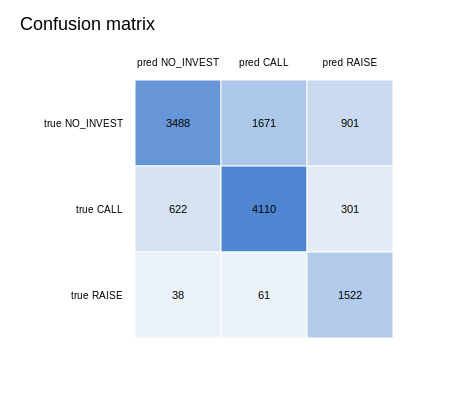

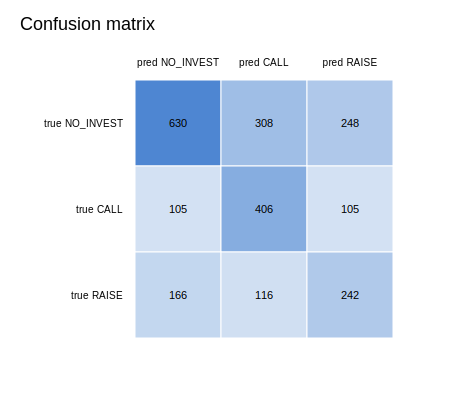

# Merged Oracle Preflop/Postflop Comparison

| model | rows | accuracy | macro F1 | recall NO_INVEST | recall CALL | recall RAISE |
|---|---:|---:|---:|---:|---:|---:|
| merged_preflop_model_v1 | 90 | 0.055556 | 0.047619 | 0.0 | 0.0 | 0.125 |
| merged_postflop_model_v1 | 90 | 1.0 | 1.0 | 1.0 | 1.0 | 1.0 |

## Warnings

- Source/domain shift is expected: PokerBench structured rows and GTO-style HF rows do not share the same distribution.
- Source dataset is used only for grouped evaluation, not as a model feature.
- PHH/ACPC remains excluded from supervised oracle training.

## Recommendation

Use these models for offline comparison only. Treat improvement as coverage evidence only after source-level and street-level performance are stable.


In [243]:
for path in [PREFLOP_MODEL_DIR / "confusion_matrix.svg", POSTFLOP_MODEL_DIR / "confusion_matrix.svg"]:
    if path.exists():
        display(SVG(filename=str(path)))

if MERGED_COMPARISON_PATH.exists():
    report_mtime = max(PREFLOP_REPORT_PATH.stat().st_mtime, POSTFLOP_REPORT_PATH.stat().st_mtime)
    if MERGED_COMPARISON_PATH.stat().st_mtime < report_mtime:
        display(Markdown("**Attention:** rapport de comparaison plus ancien que les rapports modele. Regenerer l'entrainement avant de l'interpreter."))
    else:
        display(Markdown(MERGED_COMPARISON_PATH.read_text(encoding="utf-8")))

### 15.7 Ce que tu fais apr?s

1. Regarde d'abord `macro_f1`, `recall_CALL`, `recall_RAISE` et les performances par source.
2. Si une source externe baisse fortement les m?triques, ne la m?lange pas encore avec PokerBench complet.
3. Pour une ?tude rapide, mets `MERGED_SAMPLE_SIZE = 1000`, `FORCE_MERGE = True`, `FORCE_MERGED_TRAINING = True`.
4. Pour l'?tude compl?te, laisse `MERGED_SAMPLE_SIZE = None` et force seulement quand les exports sources ont chang?.
5. Ne branche pas ces mod?les au live: ils servent ? comparer la couverture pr?flop/postflop et le domain shift.

<!-- merged_oracle_v2_full_experiment -->
## 16. V2 full merge : mod?les pr?flop/postflop et analyse finale

Cette section reconstruit l'exp?rience V2 complete: exports externes full, merge explicite avec PokerBench, entra?nement pr?flop/postflop, puis rapport final. PHH/ACPC reste exclu du supervised training.

In [244]:
# 16.1 Parametres V2 full
RUN_V2_EXTERNAL_EXPORTS = True
RUN_V2_MERGE = True
RUN_V2_TRAINING = True
FORCE_V2_EXTERNAL_EXPORTS = True
FORCE_V2_MERGE = True
FORCE_V2_TRAINING = True
V2_SAMPLE_SIZE = None

V2_POKER_GTO_DIR = ROOT / "outputs/readiness/poker_gto_100k_oracle_v2_full"
V2_GTOW_DIR = ROOT / "outputs/readiness/gtow_llama_sft_v3_oracle_v2_full"
V2_POKERBENCH_DIR = ROOT / "outputs/readiness/pokerbench_oracle_dataset_v1"
V2_MERGED_DIR = ROOT / "outputs/readiness/merged_oracle_3intent_v2_full"
V2_PREFLOP_DIR = ROOT / "outputs/readiness/merged_oracle_preflop_model_v2_full"
V2_POSTFLOP_DIR = ROOT / "outputs/readiness/merged_oracle_postflop_model_v2_full"
V2_FINAL_REPORT = ROOT / "outputs/readiness/merged_oracle_v2_full_final_report.md"

print("V2 full defaults: execute full pipeline. Set flags False later to reuse artifacts.")

V2 full defaults: execute full pipeline. Set flags False later to reuse artifacts.


### 16.2 Export full external datasets

In [245]:
if RUN_V2_EXTERNAL_EXPORTS:
    for source, output_dir in [("poker_gto_100k", V2_POKER_GTO_DIR), ("gtow_llama_sft_v3", V2_GTOW_DIR)]:
        cmd = [sys.executable, "datasets/export_external_oracle_dataset.py", "--source", source, "--output-dir", str(output_dir)]
        if V2_SAMPLE_SIZE is not None:
            cmd += ["--sample-size", str(V2_SAMPLE_SIZE)]
        if FORCE_V2_EXTERNAL_EXPORTS:
            cmd.append("--force")
        run_cmd(cmd)
else:
    print("Exports externes V2 reutilises.")

{
  "generation_timestamp": "2026-06-01T02:42:42.056033+00:00",
  "label_distribution_3intent": {
    "CALL": 30190,
    "NO_INVEST": 52301,
    "RAISE": 17509
  },
  "leakage_warnings": [
    "raw prompt/instruction/output/chosen/rejected fields are written only to audit_candidates.csv",
    "model_input.csv excludes raw text answer fields by default"
  ],
  "missing_field_rates": {
    "action_history": 0.0,
    "bet_size": 0.82491,
    "board_cards": 0.0,
    "effective_stack": 0.0,
    "equity": 0.0021,
    "ev": 0.0,
    "hand_id": 1.0,
    "hero_cards": 0.0,
    "hero_position": 0.0,
    "label_3intent": 0.0,
    "leakage_risk_notes": 0.0,
    "legal_actions": 0.0,
    "normalized_action_4class": 0.0,
    "pot_size": 0.0,
    "raw_action": 0.0,
    "source_dataset": 0.0,
    "source_license": 0.0,
    "source_row_id": 0.0,
    "source_split": 0.0,
    "source_url": 0.0,
    "street": 0.0,
    "villain_position": 0.0
  },
  "pokerbench_feature_compatibility_file": "model_features_

### 16.3 Merge V2 full dataset

In [246]:
if RUN_V2_MERGE:
    cmd = [
        sys.executable,
        "datasets/merge_oracle_3intent_dataset.py",
        "--pokerbench-dir", str(V2_POKERBENCH_DIR),
        "--poker-gto-dir", str(V2_POKER_GTO_DIR),
        "--gtow-dir", str(V2_GTOW_DIR),
        "--output-dir", str(V2_MERGED_DIR),
    ]
    if V2_SAMPLE_SIZE is not None:
        cmd += ["--sample-size-per-source", str(V2_SAMPLE_SIZE)]
    if FORCE_V2_MERGE:
        cmd.append("--force")
    run_cmd(cmd)
else:
    print("Merge V2 reutilise.")

{
  "excluded_sources": {
    "PHH / Zenodo ACPC HUNL": "excluded: scaffold/expert hand-history source, not direct solver/GTO labels"
  },
  "feature_columns": [
    "features.pot_bb",
    "features.to_call_bb",
    "features.hero_stack_bb",
    "features.effective_stack_bb",
    "features.stack_to_pot_ratio",
    "features.to_call_pot_ratio",
    "features.has_check",
    "features.has_fold",
    "features.has_call",
    "features.has_raise",
    "features.num_players",
    "features.num_bets",
    "features.board_card_count",
    "features.action_count",
    "features.prior_check_count",
    "features.prior_call_count",
    "features.prior_bet_raise_count",
    "features.prior_fold_count",
    "metadata.street",
    "features.hero_position"
  ],
  "generation_timestamp": "2026-06-01T02:43:19.198692+00:00",
  "label_distribution": {
    "CALL": 65194,
    "NO_INVEST": 102487,
    "RAISE": 37450
  },
  "label_distribution_by_source": {
    "PokerBench": {
      "CALL": 27500,
      "NO

### 16.4 Analyse dataset V2

In [247]:
v2_merge = load_json(V2_MERGED_DIR / "merge_report.json")
display(pd.DataFrame([{
    "total_rows": sum(v2_merge.get("source_rows", {}).values()),
    "preflop": v2_merge.get("stage_group_distribution", {}).get("PREFLOP"),
    "postflop": v2_merge.get("stage_group_distribution", {}).get("POSTFLOP"),
    "unknown_excluded": v2_merge.get("unknown_stage_rows_excluded"),
}]))

display(pd.Series(v2_merge.get("source_rows", {}), name="rows").to_frame())
display(pd.Series(v2_merge.get("stage_group_distribution", {}), name="rows").to_frame())
display(pd.DataFrame(v2_merge.get("rows_by_stage_and_source", {})).fillna(0).astype(int))
display(pd.DataFrame(v2_merge.get("label_distribution_by_source", {})).fillna(0).astype(int))
display(pd.DataFrame(v2_merge.get("label_distribution_by_stage", {})).fillna(0).astype(int))
display(pd.Series(v2_merge.get("missing_feature_rates", {}), name="missing_rate").to_frame())

for filename in ["X_train_preflop.csv", "X_train_postflop.csv"]:
    header = pd.read_csv(V2_MERGED_DIR / filename, nrows=0).columns.tolist()
    forbidden = sorted(set(header) & {"source_dataset", "source_row_id", "raw_prompt", "raw_response", "raw_action", "normalized_action_4class", "label_3intent", "source_license", "source_url", "leakage_risk_notes"})
    print(filename, "forbidden_columns=", forbidden)

print("excluded_sources:", v2_merge.get("excluded_sources"))

,total_rows,preflop,postflop,unknown_excluded
0,205131,74800,130331,0


,rows
PokerBench,73200
jevonmao/gtow-llama-sft-v3,31931
jevonmao/poker-gto-100k,100000


,rows
POSTFLOP,130331
PREFLOP,74800


,POSTFLOP,PREFLOP
PokerBench,10000,63200
jevonmao/gtow-llama-sft-v3,20331,11600
jevonmao/poker-gto-100k,100000,0


,PokerBench,jevonmao/gtow-llama-sft-v3,jevonmao/poker-gto-100k
CALL,27500,7504,30190
NO_INVEST,35200,14986,52301
RAISE,10500,9441,17509


,POSTFLOP,PREFLOP
CALL,36832,28362
NO_INVEST,69840,32647
RAISE,23659,13791


,missing_rate
features.action_count,0.0
features.board_card_count,0.0
features.effective_stack_bb,0.0
features.has_call,0.0
features.has_check,0.0
features.has_fold,0.0
features.has_raise,0.0
features.hero_position,0.0
features.hero_stack_bb,0.0
features.num_bets,0.0


X_train_preflop.csv forbidden_columns= []
X_train_postflop.csv forbidden_columns= []
excluded_sources: {'PHH / Zenodo ACPC HUNL': 'excluded: scaffold/expert hand-history source, not direct solver/GTO labels'}


### 16.5 Train V2 preflop/postflop models

In [248]:
if RUN_V2_TRAINING:
    cmd = [
        sys.executable,
        "experiments/merged_oracle_preflop_postflop_v2.py",
        "--data-dir", str(V2_MERGED_DIR),
        "--output-root", str(ROOT / "outputs/readiness"),
        "--preflop-output-dir", str(V2_PREFLOP_DIR),
        "--postflop-output-dir", str(V2_POSTFLOP_DIR),
        "--final-report", str(V2_FINAL_REPORT),
    ]
    if FORCE_V2_TRAINING:
        cmd.append("--force")
    run_cmd(cmd)
else:
    print("Modeles V2 reutilises.")

{
  "comparison_report": "c:\\Users\\polo\\Pictures\\Cours Info\\Programme\\Traine_aide_decission\\outputs\\readiness\\merged_oracle_v2_full_final_report.md",
  "final_report": "c:\\Users\\polo\\Pictures\\Cours Info\\Programme\\Traine_aide_decission\\outputs\\readiness\\merged_oracle_v2_full_final_report.md",
  "postflop_report": "c:\\Users\\polo\\Pictures\\Cours Info\\Programme\\Traine_aide_decission\\outputs\\readiness\\merged_oracle_postflop_model_v2_full\\training_report.json",
  "preflop_report": "c:\\Users\\polo\\Pictures\\Cours Info\\Programme\\Traine_aide_decission\\outputs\\readiness\\merged_oracle_preflop_model_v2_full\\training_report.json",
  "reports": {
    "postflop": {
      "accuracy": 0.499847,
      "classification_report": {
        "CALL": {
          "f1-score": 0.6269580714754713,
          "precision": 0.4813827871804105,
          "recall": 0.8987494957644211,
          "support": 7437.0
        },
        "NO_INVEST": {
          "f1-score": 0.3111289306374936

### 16.6 Analyse mod?les V2

,model,rows_train,rows_validation,rows_test,accuracy,macro_f1,weighted_f1,recall_NO_INVEST,recall_CALL,recall_RAISE
0,preflop,52360,7480,14960,0.731885,0.733527,0.725520,0.564805,0.845747,0.894028
1,postflop,91232,13033,26066,0.499847,0.493906,0.442555,0.194042,0.898749,0.783463


#### Preflop by source

,accuracy,macro_f1,rows
PokerBench,0.726817,0.724069,12574
jevonmao/gtow-llama-sft-v3,0.758592,0.675473,2386


#### Postflop by source

,accuracy,macro_f1,rows
PokerBench,0.471853,0.475016,1954
jevonmao/gtow-llama-sft-v3,0.601185,0.592126,4052
jevonmao/poker-gto-100k,0.482104,0.465864,20060


#### Preflop by street

,accuracy,macro_f1,rows
PREFLOP,0.731885,0.733527,14960


#### Postflop by street

,accuracy,macro_f1,rows
FLOP,0.661489,0.636892,2189
RIVER,0.473828,0.465286,17996
TURN,0.519299,0.503002,5881


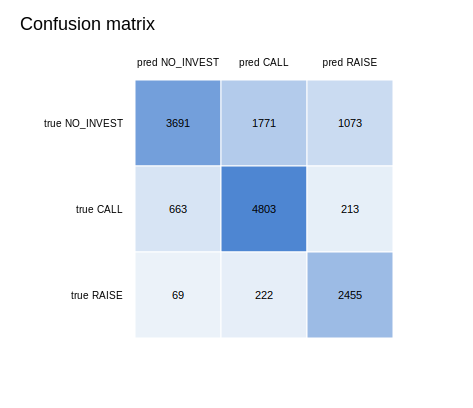

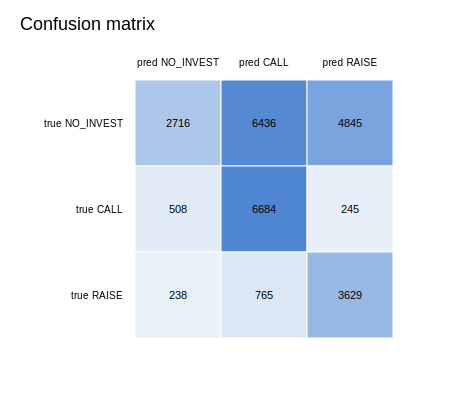

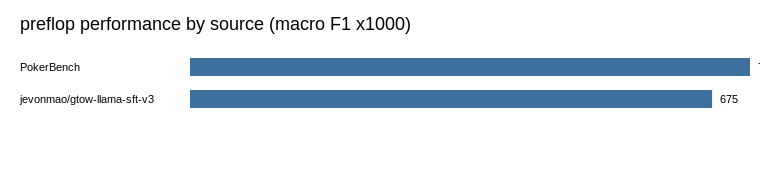

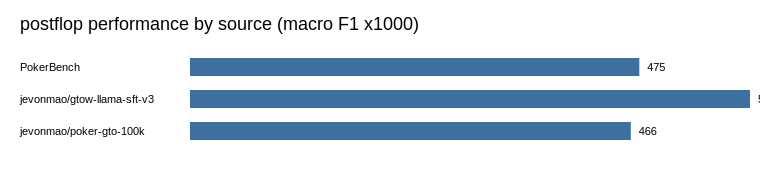

# Merged Oracle V2 Full Final Report

## Dataset Composition

- total rows: `205131`
- preflop rows: `74800`
- postflop rows: `130331`
- unknown rows excluded: `0`

### Rows By Source

```json
{
  "PokerBench": 73200,
  "jevonmao/gtow-llama-sft-v3": 31931,
  "jevonmao/poker-gto-100k": 100000
}
```

### Rows By Stage

```json
{
  "POSTFLOP": 130331,
  "PREFLOP": 74800
}
```

### Rows By Source And Stage

```json
{
  "POSTFLOP": {
    "PokerBench": 10000,
    "jevonmao/gtow-llama-sft-v3": 20331,
    "jevonmao/poker-gto-100k": 100000
  },
  "PREFLOP": {
    "PokerBench": 63200,
    "jevonmao/gtow-llama-sft-v3": 11600
  }
}
```

### Label Distribution By Source

```json
{
  "PokerBench": {
    "CALL": 27500,
    "NO_INVEST": 35200,
    "RAISE": 10500
  },
  "jevonmao/gtow-llama-sft-v3": {
    "CALL": 7504,
    "NO_INVEST": 14986,
    "RAISE": 9441
  },
  "jevonmao/poker-gto-100k": {
    "CALL": 30190,
    "NO_INVEST": 52301,
    "RAISE": 17509
  }
}
```

### Label Distribution By Stage

```json
{
  "POSTFLOP": {
    "CALL": 36832,
    "NO_INVEST": 69840,
    "RAISE": 23659
  },
  "PREFLOP": {
    "CALL": 28362,
    "NO_INVEST": 32647,
    "RAISE": 13791
  }
}
```

## Model Comparison

| model | rows | accuracy | macro_f1 | weighted_f1 | recall_NO_INVEST | recall_CALL | recall_RAISE |
|---|---:|---:|---:|---:|---:|---:|---:|
| V2 preflop | 74800 | 0.731885 | 0.733527 | 0.72552 | 0.564805 | 0.845747 | 0.894028 |
| V2 postflop | 130331 | 0.499847 | 0.493906 | 0.442555 | 0.194042 | 0.898749 | 0.783463 |

## Source-Level Performance

### Preflop

```json
{
  "PokerBench": {
    "accuracy": 0.726817,
    "macro_f1": 0.724069,
    "rows": 12574
  },
  "jevonmao/gtow-llama-sft-v3": {
    "accuracy": 0.758592,
    "macro_f1": 0.675473,
    "rows": 2386
  }
}
```

### Postflop

```json
{
  "PokerBench": {
    "accuracy": 0.471853,
    "macro_f1": 0.475016,
    "rows": 1954
  },
  "jevonmao/gtow-llama-sft-v3": {
    "accuracy": 0.601185,
    "macro_f1": 0.592126,
    "rows": 4052
  },
  "jevonmao/poker-gto-100k": {
    "accuracy": 0.482104,
    "macro_f1": 0.465864,
    "rows": 20060
  }
}
```

## Warnings

- Domain shift is expected between PokerBench, poker-gto-100k, and gtow-llama-sft-v3.
- External source license and GTO Wizard terms must be verified before redistribution or commercial use.
- PHH/ACPC is excluded from supervised training because it is a scaffold/expert history source, not a direct oracle-label source.
- Raw prompt/instruction/output/chosen/rejected text is excluded from model inputs.
- `source_dataset` is excluded from model features and used only for grouped evaluation.

## Final Recommendation

- V2 improves coverage by adding external HU/GTO-style data, but source imbalance remains dominated by PokerBench unless full external exports are much larger.
- The preflop model is the stronger offline candidate if source-level performance is stable.
- The postflop model remains weaker and likely needs card, board texture, equity, range, and sizing features beyond the 20-feature contract.
- For V3, compare source weighting/downsampling and consider excluding or separately routing any source that degrades source-level recall.


In [249]:
v2_pre = load_json(V2_PREFLOP_DIR / "training_report.json")
v2_post = load_json(V2_POSTFLOP_DIR / "training_report.json")
rows = []
for name, item in [("preflop", v2_pre), ("postflop", v2_post)]:
    rows.append({
        "model": name,
        "rows_train": item.get("rows_train"),
        "rows_validation": item.get("rows_validation"),
        "rows_test": item.get("rows_test"),
        "accuracy": item.get("accuracy"),
        "macro_f1": item.get("macro_f1"),
        "weighted_f1": item.get("weighted_f1"),
        "recall_NO_INVEST": item.get("recall_NO_INVEST"),
        "recall_CALL": item.get("recall_CALL"),
        "recall_RAISE": item.get("recall_RAISE"),
    })
display(pd.DataFrame(rows))

for title, item in [("Preflop by source", v2_pre), ("Postflop by source", v2_post), ("Preflop by street", v2_pre), ("Postflop by street", v2_post)]:
    key = "performance_by_street" if "street" in title else "performance_by_source_dataset"
    display(Markdown(f"#### {title}"))
    display(pd.DataFrame.from_dict(item.get(key, {}), orient="index"))

for svg_path in [V2_PREFLOP_DIR / "confusion_matrix.svg", V2_POSTFLOP_DIR / "confusion_matrix.svg", V2_PREFLOP_DIR / "performance_by_source.svg", V2_POSTFLOP_DIR / "performance_by_source.svg"]:
    if svg_path.exists():
        display(SVG(filename=str(svg_path)))

if V2_FINAL_REPORT.exists():
    latest_model_report = max((V2_PREFLOP_DIR / "training_report.json").stat().st_mtime, (V2_POSTFLOP_DIR / "training_report.json").stat().st_mtime)
    if V2_FINAL_REPORT.stat().st_mtime < latest_model_report:
        display(Markdown("**Attention:** rapport V2 final plus ancien que les rapports modeles."))
    else:
        display(Markdown(V2_FINAL_REPORT.read_text(encoding="utf-8")))

### 16.7 D?cision finale V2

- V2 am?liore fortement la couverture: les sources externes ajoutent beaucoup de postflop HU/GTO et du pr?flop GTOW.
- Le mod?le pr?flop reste plus solide que le postflop dans cette architecture 20 features.
- Le postflop a besoin de features de cartes, texture board, ?quit?, EV, sizing et range context; le contrat 20 features est trop pauvre pour tout absorber.
- Les sources externes doivent rester tra?ables par `source_dataset`; pour V3, tester pond?ration/downsampling ou routeurs par source.
- PHH/ACPC reste hors supervised oracle tant qu'il n'est pas relabelis? par solver ou s?par? en imitation learning.

<!-- model_comparison_dashboard_v1 -->
## 17. Dashboard comparaison mod?les pr?flop vs postflop

Cette section lit les rapports V2 existants et construit un dashboard visuel sans relancer l'entrainement.

### 17.1 Load reports

In [250]:

from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, SVG

DASHBOARD_DIR = Path("outputs/readiness/model_comparison_dashboard_v1")
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

PREFLOP_REPORT_PATH = Path("outputs/readiness/merged_oracle_preflop_model_v2_full/training_report.json")
POSTFLOP_REPORT_PATH = Path("outputs/readiness/merged_oracle_postflop_model_v2_full/training_report.json")
MERGE_REPORT_PATH = Path("outputs/readiness/merged_oracle_3intent_v2_full/merge_report.json")

LABELS = ["NO_INVEST", "CALL", "RAISE"]
MODELS = ["preflop", "postflop"]
chart_files = []


def safe_get(obj, path, default=None):
    """Read nested dict/list values without crashing when a key is absent."""
    cur = obj
    for part in path:
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(part, default)
        elif isinstance(cur, (list, tuple)) and isinstance(part, int) and 0 <= part < len(cur):
            cur = cur[part]
        else:
            return default
    return cur


def load_json_or_warn(path):
    path = Path(path)
    if not path.exists():
        display(Markdown(f"Attention: Rapport manquant: `{path}`. La section continue avec des valeurs vides."))
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        display(Markdown(f"Attention: Impossible de lire `{path}`: `{exc}`. La section continue avec des valeurs vides."))
        return None


def to_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def extract_class_metric(report, class_name, metric_name):
    if report is None:
        return np.nan
    if metric_name == "precision":
        value = safe_get(report, ["precision_per_class", class_name])
        if value is not None:
            return to_float(value)
    return to_float(safe_get(report, ["classification_report", class_name, metric_name]))


def report_to_metrics_row(report, model_name):
    row = {"model": model_name}
    for key in ["rows_train", "rows_validation", "rows_test", "accuracy", "macro_f1", "weighted_f1", "recall_NO_INVEST", "recall_CALL", "recall_RAISE"]:
        row[key] = to_float(safe_get(report, [key]))
    for label in LABELS:
        row[f"precision_{label}"] = extract_class_metric(report, label, "precision")
    return row


def percent(x):
    return "n/a" if pd.isna(x) else f"{x:.2%}"


def number(x):
    return "n/a" if pd.isna(x) else f"{int(x):,}".replace(",", " ")


def save_current_fig(filename):
    path = DASHBOARD_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight")
    chart_files.append(path)
    display(SVG(filename=str(path)))
    plt.close()
    return path

preflop_report = load_json_or_warn(PREFLOP_REPORT_PATH)
postflop_report = load_json_or_warn(POSTFLOP_REPORT_PATH)
merge_report = load_json_or_warn(MERGE_REPORT_PATH)
reports = {"preflop": preflop_report, "postflop": postflop_report}

display(Markdown(
    "Rapports charges: "
    f"preflop={'oui' if preflop_report else 'non'}, "
    f"postflop={'oui' if postflop_report else 'non'}, "
    f"merge={'oui' if merge_report else 'non'}."
))


Rapports charges: preflop=oui, postflop=oui, merge=oui.

### 17.2 Global comparison table

In [251]:

metric_rows = [
    report_to_metrics_row(preflop_report, "preflop"),
    report_to_metrics_row(postflop_report, "postflop"),
]
global_metrics_df = pd.DataFrame(metric_rows).set_index("model")

count_cols = ["rows_train", "rows_validation", "rows_test"]
percent_cols = [c for c in global_metrics_df.columns if c not in count_cols]


def style_global_metrics(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in percent_cols:
        values = pd.to_numeric(df[col], errors="coerce")
        valid = values.dropna()
        if valid.empty:
            continue
        best = valid.max()
        for idx, value in values.items():
            cell_styles = []
            if pd.notna(value) and math.isclose(value, best, rel_tol=1e-9, abs_tol=1e-9):
                cell_styles.append("background-color: #d9ead3; font-weight: 600")
            if pd.notna(value) and value < 0.50:
                cell_styles.append("background-color: #f4cccc")
            styles.loc[idx, col] = "; ".join(cell_styles)
    return styles

formatters = {col: number for col in count_cols}
formatters.update({col: percent for col in percent_cols})

display(global_metrics_df.style.format(formatters).apply(style_global_metrics, axis=None))


,rows_train,rows_validation,rows_test,accuracy,macro_f1,weighted_f1,recall_NO_INVEST,recall_CALL,recall_RAISE,precision_NO_INVEST,precision_CALL,precision_RAISE
model,,,,,,,,,,,,
preflop,52 360,7 480,14 960,73.19%,73.35%,72.55%,56.48%,84.57%,89.40%,83.45%,70.67%,65.62%
postflop,91 232,13 033,26 066,49.98%,49.39%,44.26%,19.40%,89.87%,78.35%,78.45%,48.14%,41.62%


### 17.3 Metric delta table

In [252]:

delta_metrics = ["accuracy", "macro_f1", "weighted_f1", "recall_NO_INVEST", "recall_CALL", "recall_RAISE"]
delta_rows = []
interpretation_lines = []

for metric in delta_metrics:
    pre = to_float(global_metrics_df.loc["preflop", metric]) if metric in global_metrics_df.columns else np.nan
    post = to_float(global_metrics_df.loc["postflop", metric]) if metric in global_metrics_df.columns else np.nan
    delta = pre - post if pd.notna(pre) and pd.notna(post) else np.nan
    if pd.isna(delta):
        winner = "not available"
        interpretation = f"{metric}: donnees insuffisantes."
    elif delta > 0.10:
        winner = "preflop"
        interpretation = f"{metric}: preflop est clairement plus fort (+{delta:.2%})."
    elif delta < -0.10:
        winner = "postflop"
        interpretation = f"{metric}: postflop est clairement plus fort ({delta:.2%})."
    else:
        winner = "similar"
        interpretation = f"{metric}: performances proches ({delta:.2%})."
    delta_rows.append({
        "metric": metric,
        "preflop": pre,
        "postflop": post,
        "delta_preflop_minus_postflop": delta,
        "winner": winner,
    })
    interpretation_lines.append(f"- {interpretation}")

delta_df = pd.DataFrame(delta_rows)
display(delta_df.style.format({
    "preflop": percent,
    "postflop": percent,
    "delta_preflop_minus_postflop": lambda x: "n/a" if pd.isna(x) else f"{x:+.2%}",
}))
display(Markdown("\n".join(interpretation_lines)))


,metric,preflop,postflop,delta_preflop_minus_postflop,winner
0,accuracy,73.19%,49.98%,+23.20%,preflop
1,macro_f1,73.35%,49.39%,+23.96%,preflop
2,weighted_f1,72.55%,44.26%,+28.30%,preflop
3,recall_NO_INVEST,56.48%,19.40%,+37.08%,preflop
4,recall_CALL,84.57%,89.87%,-5.30%,similar
5,recall_RAISE,89.40%,78.35%,+11.06%,preflop


- accuracy: preflop est clairement plus fort (+23.20%).
- macro_f1: preflop est clairement plus fort (+23.96%).
- weighted_f1: preflop est clairement plus fort (+28.30%).
- recall_NO_INVEST: preflop est clairement plus fort (+37.08%).
- recall_CALL: performances proches (-5.30%).
- recall_RAISE: preflop est clairement plus fort (+11.06%).

### 17.4 Bar charts

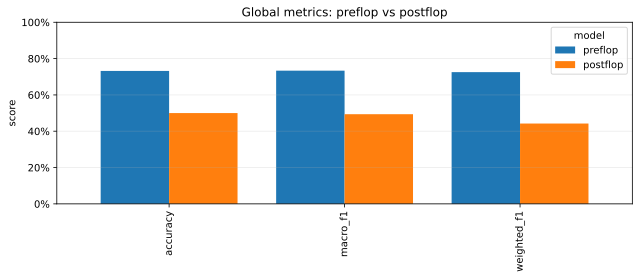

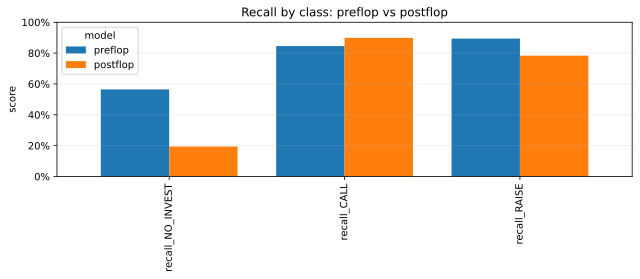

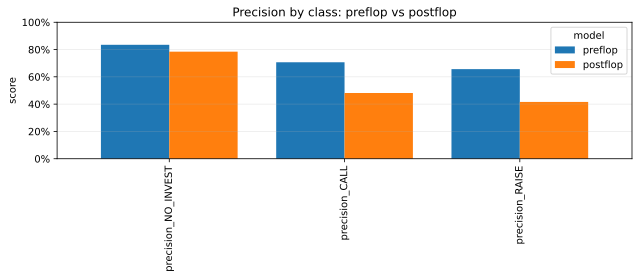

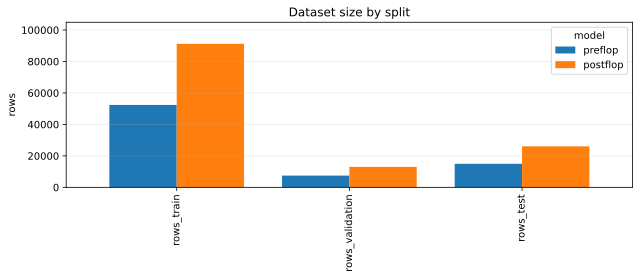

WindowsPath('outputs/readiness/model_comparison_dashboard_v1/dataset_size_preflop_vs_postflop.svg')

In [253]:

def plot_model_metric_bars(df, metrics, title, ylabel, filename):
    available = [m for m in metrics if m in df.columns]
    if not available:
        display(Markdown(f"Attention: Aucune metrique disponible pour `{filename}`."))
        return None
    plot_df = df[available].T
    ax = plot_df.plot(kind="bar", figsize=(9, 4), width=0.78)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_ylim(0, 1 if ylabel == "score" else max(1, float(np.nanmax(plot_df.values)) * 1.15))
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="model")
    if ylabel == "score":
        ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    return save_current_fig(filename)

plot_model_metric_bars(
    global_metrics_df,
    ["accuracy", "macro_f1", "weighted_f1"],
    "Global metrics: preflop vs postflop",
    "score",
    "global_metrics_preflop_vs_postflop.svg",
)

plot_model_metric_bars(
    global_metrics_df,
    ["recall_NO_INVEST", "recall_CALL", "recall_RAISE"],
    "Recall by class: preflop vs postflop",
    "score",
    "recall_by_class_preflop_vs_postflop.svg",
)

plot_model_metric_bars(
    global_metrics_df,
    ["precision_NO_INVEST", "precision_CALL", "precision_RAISE"],
    "Precision by class: preflop vs postflop",
    "score",
    "precision_by_class_preflop_vs_postflop.svg",
)

plot_model_metric_bars(
    global_metrics_df,
    ["rows_train", "rows_validation", "rows_test"],
    "Dataset size by split",
    "rows",
    "dataset_size_preflop_vs_postflop.svg",
)


### 17.5 Confusion matrices side by side

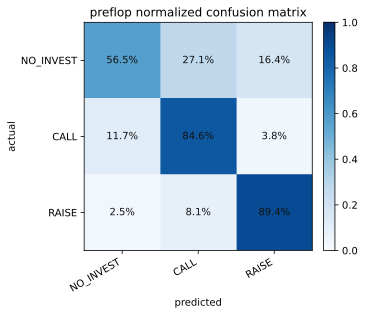

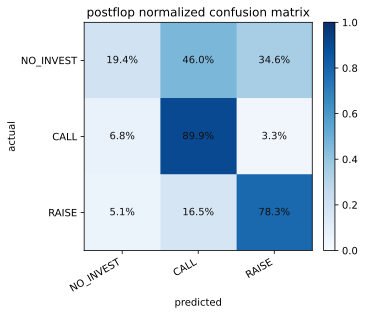

- preflop: confusion principale `NO_INVEST` -> `CALL` (1771/6535). NO_INVEST n'est pas sous-detecte fortement. CALL/RAISE ne sont pas clairement sur-predits.
- postflop: confusion principale `NO_INVEST` -> `CALL` (6436/13997). NO_INVEST est sous-detecte. CALL, RAISE sont sur-predits.

In [254]:

def confusion_matrix_df(report):
    cm = safe_get(report, ["confusion_matrix"], {}) or {}
    df = pd.DataFrame(0.0, index=LABELS, columns=LABELS)
    if isinstance(cm, dict):
        for actual, preds in cm.items():
            if actual not in df.index or not isinstance(preds, dict):
                continue
            for pred, count in preds.items():
                if pred in df.columns:
                    df.loc[actual, pred] = to_float(count)
    return df


def normalized_confusion_matrix(df):
    row_sums = df.sum(axis=1).replace(0, np.nan)
    return df.div(row_sums, axis=0).fillna(0.0)


def plot_confusion_matrix(report, model_name, filename):
    raw_df = confusion_matrix_df(report)
    norm_df = normalized_confusion_matrix(raw_df)
    fig, ax = plt.subplots(figsize=(5.3, 4.5))
    im = ax.imshow(norm_df.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{model_name} normalized confusion matrix")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_xticks(range(len(LABELS)), LABELS, rotation=30, ha="right")
    ax.set_yticks(range(len(LABELS)), LABELS)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, f"{norm_df.iloc[i, j]:.1%}", ha="center", va="center", color="#111")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return save_current_fig(filename), raw_df, norm_df


def confusion_interpretation(report, model_name):
    raw_df = confusion_matrix_df(report)
    if raw_df.values.sum() == 0:
        return f"- {model_name}: matrice indisponible."
    off_diag = raw_df.copy()
    for label in LABELS:
        off_diag.loc[label, label] = 0
    actual, predicted = off_diag.stack().idxmax()
    count = int(off_diag.loc[actual, predicted])
    total_actual = int(raw_df.loc[actual].sum()) or 1
    recall_no_invest = extract_class_metric(report, "NO_INVEST", "recall")
    pred_totals = raw_df.sum(axis=0)
    actual_totals = raw_df.sum(axis=1)
    total = raw_df.values.sum() or 1
    over_predicted = []
    for label in ["CALL", "RAISE"]:
        pred_share = pred_totals[label] / total
        actual_share = actual_totals[label] / total
        if pred_share > actual_share + 0.10:
            over_predicted.append(label)
    no_invest_text = "NO_INVEST est sous-detecte" if pd.notna(recall_no_invest) and recall_no_invest < 0.50 else "NO_INVEST n'est pas sous-detecte fortement"
    over_text = (over_predicted[0] + " est sur-predit") if len(over_predicted) == 1 else ((", ".join(over_predicted) + " sont sur-predits") if over_predicted else "CALL/RAISE ne sont pas clairement sur-predits")
    return f"- {model_name}: confusion principale `{actual}` -> `{predicted}` ({count}/{total_actual}). {no_invest_text}. {over_text}."

pre_cm_path, pre_cm_raw, pre_cm_norm = plot_confusion_matrix(preflop_report, "preflop", "preflop_confusion_matrix_normalized.svg")
post_cm_path, post_cm_raw, post_cm_norm = plot_confusion_matrix(postflop_report, "postflop", "postflop_confusion_matrix_normalized.svg")

confusion_notes = [
    confusion_interpretation(preflop_report, "preflop"),
    confusion_interpretation(postflop_report, "postflop"),
]

display(HTML(
    f"<div style='display:flex; gap:24px; align-items:flex-start;'>"
    f"<div><b>Preflop</b><br><img src='{pre_cm_path.as_posix()}' style='max-width:480px;'></div>"
    f"<div><b>Postflop</b><br><img src='{post_cm_path.as_posix()}' style='max-width:480px;'></div>"
    "</div>"
))
display(Markdown("\n".join(confusion_notes)))


### 17.6 Performance by source dataset

,source_dataset,model,rows,accuracy,macro_f1
0,PokerBench,preflop,12574.0,0.726817,0.724069
1,PokerBench,postflop,1954.0,0.471853,0.475016
2,jevonmao/gtow-llama-sft-v3,preflop,2386.0,0.758592,0.675473
3,jevonmao/gtow-llama-sft-v3,postflop,4052.0,0.601185,0.592126
4,jevonmao/poker-gto-100k,preflop,not available,not available,not available
5,jevonmao/poker-gto-100k,postflop,20060.0,0.482104,0.465864


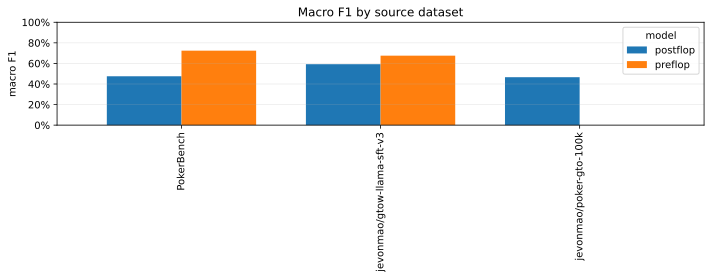

In [255]:

def performance_rows(report, model_name, key_name, dimension_name):
    data = safe_get(report, [key_name], {}) or {}
    rows = []
    for name, values in data.items():
        rows.append({
            dimension_name: name,
            "model": model_name,
            "rows": to_float(safe_get(values, ["rows"])),
            "accuracy": to_float(safe_get(values, ["accuracy"])),
            "macro_f1": to_float(safe_get(values, ["macro_f1"])),
        })
    return rows

source_rows = []
for model_name, report in reports.items():
    source_rows.extend(performance_rows(report, model_name, "performance_by_source_dataset", "source_dataset"))
source_perf_df = pd.DataFrame(source_rows)

if source_perf_df.empty:
    display(Markdown("Attention: Performance par source indisponible dans les rapports."))
else:
    all_sources = sorted(source_perf_df["source_dataset"].dropna().unique().tolist())
    full_index = pd.MultiIndex.from_product([all_sources, MODELS], names=["source_dataset", "model"]).to_frame(index=False)
    source_perf_df = full_index.merge(source_perf_df, on=["source_dataset", "model"], how="left")
    display(source_perf_df.fillna("not available"))

    pivot = source_perf_df.pivot(index="source_dataset", columns="model", values="macro_f1")
    ax = pivot.plot(kind="bar", figsize=(10, 4), width=0.75)
    ax.set_title("Macro F1 by source dataset")
    ax.set_ylabel("macro F1")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    save_current_fig("performance_by_source_preflop_vs_postflop.svg")


### 17.7 Performance by street

,street,model,rows,accuracy,macro_f1
0,PREFLOP,preflop,14960.0,0.731885,0.733527
1,FLOP,postflop,2189.0,0.661489,0.636892
3,TURN,postflop,5881.0,0.519299,0.503002
2,RIVER,postflop,17996.0,0.473828,0.465286


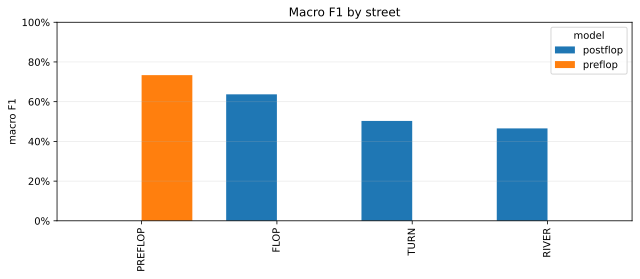

In [256]:

street_rows = []
for model_name, report in reports.items():
    street_rows.extend(performance_rows(report, model_name, "performance_by_street", "street"))
street_perf_df = pd.DataFrame(street_rows)

if street_perf_df.empty:
    display(Markdown("Attention: Performance par street indisponible dans les rapports."))
else:
    street_order = ["PREFLOP", "FLOP", "TURN", "RIVER"]
    street_perf_df["street"] = pd.Categorical(street_perf_df["street"], categories=street_order, ordered=True)
    street_perf_df = street_perf_df.sort_values(["street", "model"])
    display(street_perf_df.fillna("not available"))

    pivot = street_perf_df.pivot(index="street", columns="model", values="macro_f1").reindex(street_order)
    ax = pivot.plot(kind="bar", figsize=(9, 4), width=0.75)
    ax.set_title("Macro F1 by street")
    ax.set_ylabel("macro F1")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    save_current_fig("performance_by_street.svg")


### 17.8 Label distribution comparison

,model,label,count,percentage
0,preflop,NO_INVEST,32 647,43.65%
1,preflop,CALL,28 362,37.92%
2,preflop,RAISE,13 791,18.44%
3,postflop,NO_INVEST,69 840,53.59%
4,postflop,CALL,36 832,28.26%
5,postflop,RAISE,23 659,18.15%


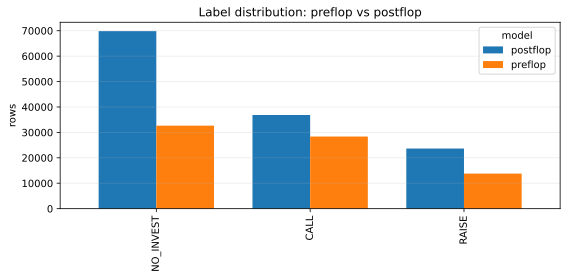

- Pas de label au-dessus de 60% ou sous 10% dans les distributions globales.

In [257]:

def label_distribution_rows(report, model_name):
    dist = safe_get(report, ["label_distribution"], {}) or {}
    total = sum(to_float(v) for v in dist.values() if pd.notna(to_float(v)))
    rows = []
    for label in LABELS:
        count = to_float(dist.get(label))
        pct = count / total if total and pd.notna(count) else np.nan
        rows.append({"model": model_name, "label": label, "count": count, "percentage": pct})
    return rows

label_dist_df = pd.DataFrame(label_distribution_rows(preflop_report, "preflop") + label_distribution_rows(postflop_report, "postflop"))
display(label_dist_df.style.format({"count": number, "percentage": percent}))

pivot_counts = label_dist_df.pivot(index="label", columns="model", values="count").reindex(LABELS)
ax = pivot_counts.plot(kind="bar", figsize=(8, 4), width=0.75)
ax.set_title("Label distribution: preflop vs postflop")
ax.set_ylabel("rows")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
save_current_fig("label_distribution_preflop_vs_postflop.svg")

imbalance_warnings = []
for model_name in MODELS:
    subset = label_dist_df[label_dist_df["model"] == model_name]
    for _, row in subset.iterrows():
        pct = row["percentage"]
        if pd.isna(pct):
            continue
        if pct > 0.60:
            imbalance_warnings.append(f"- {model_name}: `{row['label']}` depasse 60% ({pct:.1%}).")
        if pct < 0.10:
            imbalance_warnings.append(f"- {model_name}: `{row['label']}` est sous 10% ({pct:.1%}).")
if imbalance_warnings:
    imbalance_warnings.append("- Un desequilibre de classes peut expliquer une partie du faible recall.")
else:
    imbalance_warnings.append("- Pas de label au-dessus de 60% ou sous 10% dans les distributions globales.")
display(Markdown("\n".join(imbalance_warnings)))


### 17.9 Diagnostic final preflop vs postflop

In [258]:

def winner_for(metric):
    pre = to_float(global_metrics_df.loc["preflop", metric]) if metric in global_metrics_df.columns else np.nan
    post = to_float(global_metrics_df.loc["postflop", metric]) if metric in global_metrics_df.columns else np.nan
    if pd.isna(pre) or pd.isna(post):
        return "indisponible", pre, post
    return ("preflop" if pre > post else "postflop" if post > pre else "egal"), pre, post

macro_winner, pre_macro, post_macro = winner_for("macro_f1")
call_winner, pre_call, post_call = winner_for("recall_CALL")
raise_winner, pre_raise, post_raise = winner_for("recall_RAISE")
no_invest_winner, pre_no, post_no = winner_for("recall_NO_INVEST")
accuracy_winner, pre_acc, post_acc = winner_for("accuracy")

def majority_baseline(report):
    dist = safe_get(report, ["label_distribution_test"], None) or safe_get(report, ["label_distribution"], {}) or {}
    counts = [to_float(v) for v in dist.values()]
    counts = [v for v in counts if pd.notna(v)]
    total = sum(counts)
    return max(counts) / total if total else np.nan

post_majority = majority_baseline(postflop_report)
postflop_weaker_than_baseline = pd.notna(post_majority) and pd.notna(post_acc) and post_acc < post_majority

stronger_overall = "preflop" if (pd.notna(pre_macro) and pd.notna(post_macro) and pre_macro >= post_macro) else "postflop"
preflop_offline_ok = pd.notna(pre_macro) and pd.notna(pre_acc) and pre_macro >= 0.65 and pre_acc >= 0.65
postflop_needs_texture = pd.notna(post_no) and post_no < 0.50

final_diagnosis_lines = [
    f"### Diagnostic final preflop vs postflop",
    f"{stronger_overall.capitalize()} est actuellement le modele le plus fort globalement.",
    f"Macro F1: gagnant `{macro_winner}` (preflop={percent(pre_macro)}, postflop={percent(post_macro)}).",
    f"CALL recall: gagnant `{call_winner}` (preflop={percent(pre_call)}, postflop={percent(post_call)}).",
    f"RAISE recall: gagnant `{raise_winner}` (preflop={percent(pre_raise)}, postflop={percent(post_raise)}).",
    f"NO_INVEST recall: gagnant `{no_invest_winner}` (preflop={percent(pre_no)}, postflop={percent(post_no)}).",
]

if pd.notna(post_majority):
    baseline_text = "plus faible" if postflop_weaker_than_baseline else "au-dessus"
    final_diagnosis_lines.append(f"Postflop est {baseline_text} que sa baseline classe majoritaire (baseline={percent(post_majority)}, accuracy={percent(post_acc)}).")
else:
    final_diagnosis_lines.append("Baseline classe majoritaire postflop indisponible.")

final_diagnosis_lines.append(
    "Postflop a probablement besoin de features cartes/board texture et d'un meilleur parsing sizing/to_call."
    if postflop_needs_texture else
    "Postflop reste a surveiller, mais le recall NO_INVEST n'indique pas seul un manque critique de texture."
)
final_diagnosis_lines.append(
    "Preflop est acceptable comme baseline offline." if preflop_offline_ok else "Preflop n'est pas encore assez solide comme baseline offline."
)
final_diagnosis_lines.append("Recommendation V3: prioriser l'ingenierie postflop avant d'ajouter davantage de datasets.")

final_diagnosis_md = "\n\n".join(final_diagnosis_lines)
display(Markdown(final_diagnosis_md))


### Diagnostic final preflop vs postflop

Preflop est actuellement le modele le plus fort globalement.

Macro F1: gagnant `preflop` (preflop=73.35%, postflop=49.39%).

CALL recall: gagnant `postflop` (preflop=84.57%, postflop=89.87%).

RAISE recall: gagnant `preflop` (preflop=89.40%, postflop=78.35%).

NO_INVEST recall: gagnant `preflop` (preflop=56.48%, postflop=19.40%).

Postflop est plus faible que sa baseline classe majoritaire (baseline=53.70%, accuracy=49.98%).

Postflop a probablement besoin de features cartes/board texture et d'un meilleur parsing sizing/to_call.

Preflop est acceptable comme baseline offline.

Recommendation V3: prioriser l'ingenierie postflop avant d'ajouter davantage de datasets.

### 17.10 Export dashboard summary

In [259]:

def df_to_markdown_safe(df):
    if df is None or df.empty:
        return "_not available_"
    flat = df.reset_index(drop=True).copy()
    flat = flat.where(pd.notna(flat), "not available")

    def cell_to_text(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.6g}"
        return str(value)

    text_df = flat.map(cell_to_text)
    headers = [str(col) for col in text_df.columns]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for _, row in text_df.iterrows():
        lines.append("| " + " | ".join(row.tolist()) + " |")
    return "\n".join(lines)

summary_path = DASHBOARD_DIR / "preflop_vs_postflop_dashboard.md"
chart_list_md = "\n".join(f"- `{path.as_posix()}`" for path in chart_files)

summary_parts = [
    "# Dashboard preflop vs postflop",
    "",
    "## Global metrics",
    df_to_markdown_safe(global_metrics_df.reset_index()),
    "",
    "## Delta metrics",
    df_to_markdown_safe(delta_df),
    "",
    "## Label distribution",
    df_to_markdown_safe(label_dist_df),
    "",
    "## Confusion matrix interpretation",
    "\n".join(confusion_notes),
    "",
    "## Performance by source",
    df_to_markdown_safe(source_perf_df if 'source_perf_df' in globals() else pd.DataFrame()),
    "",
    "## Final diagnosis",
    final_diagnosis_md,
    "",
    "## Generated chart files",
    chart_list_md or "_No chart generated._",
]
summary_path.write_text("\n".join(summary_parts), encoding="utf-8")
display(Markdown(f"Dashboard exporte: `{summary_path}`"))


Dashboard exporte: `outputs\readiness\model_comparison_dashboard_v1\preflop_vs_postflop_dashboard.md`